Fair Modeling - Classification / Regression

1. Fair Classification
- Disparate Impact
- Demographic Parity
- Equal Opportunity
- Equalized Odds


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error



In [2]:
pip install fairlearn #torch sklearn matplotlib pandas numpy

In [3]:
from fairlearn.datasets import fetch_adult
# 데이터 로드
data = fetch_adult(as_frame=True)
X, y, S = data.data.drop(columns=['sex']), data.target, data.data['sex']  # sensitibe attribute: 'sex'
# One-Hot Encodeing & Zero imputation
X = pd.get_dummies(X).fillna(0) # zero imputation 은 training/testing 굳이 구분 필요 없죠.
# One-Hot Encodeing (Male=1, Female=0)
S = (S == 'Male').astype(int)
# One-Hot Encodeing (Male=1, Female=0)
y = pd.get_dummies(y, drop_first=True).astype(int)

In [4]:
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [5]:
# Neural Network Model for Binary Classification
class classifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
            )
    def forward(self, x):
        return self.fc(x)

# Neural Network Model for Regression
class regressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            )
    def forward(self, x):
        return self.fc(x)


In [6]:
# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# 데이터 분리
X_train, X_test, y_train, y_test, S_train, S_test = train_test_split(X, y, S, test_size=0.2, random_state=seed)

# Normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tensor 변환
X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train.values).float()
S_train_t = torch.tensor(S_train.values).float()
X_test_t = torch.tensor(X_test).float()
S_test_t = torch.tensor(S_test.values).float()
y_test_t = torch.tensor(y_test.values).float()

Fair Modeling
- Disparate Impact: 그룹 간 "예측값" 차이 최소화 (비율)
- Demographic Parity: 그룹 간 "예측값" 차이 최소화
- Equal Opportunity: 그룹 간 "예측성능" TPR(정답률)
- Equalized Odds: 그룹 간 "예측성능" TPR(정답률)과 FPR(오류율) 차이 최소화



In [7]:
# Fair Modeling: Equalized Opportunity
model = classifier(X_train.shape[1])
criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 30
lambda_fair = 10

for epoch in range(epochs):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = criterion(y_pred, y_train_t)

  # TPR 계산 (Y=1)
  pos_A = (S_train_t == 0) & (y_train_t.squeeze() == 1)
  pos_B = (S_train_t == 1) & (y_train_t.squeeze() == 1)

  tpr_A = y_pred[pos_A].mean()
  tpr_B = y_pred[pos_B].mean()

  loss_fair = torch.abs(tpr_A - tpr_B)

  loss_total = loss + lambda_fair * loss_fair
  loss_total.backward()
  print("loss", loss)
  print("loss_fair", loss_fair)
  optimizer.step()


loss tensor(0.6999, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0215, grad_fn=<AbsBackward0>)
loss tensor(0.6730, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0359, grad_fn=<AbsBackward0>)
loss tensor(0.6505, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0320, grad_fn=<AbsBackward0>)
loss tensor(0.6335, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0130, grad_fn=<AbsBackward0>)
loss tensor(0.6206, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0108, grad_fn=<AbsBackward0>)
loss tensor(0.6042, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0174, grad_fn=<AbsBackward0>)
loss tensor(0.5866, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0143, grad_fn=<AbsBackward0>)
loss tensor(0.5687, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0053, grad_fn=<AbsBackward0>)
loss tensor(0.5513, grad_fn=<BinaryCrossEntropyBackward0>)
loss_fair tensor(0.0072, grad_fn=<AbsBackward0>)
loss tensor(0.5364, grad_fn=

In [8]:
y_pred, y_train_t, S_train_t

(tensor([[0.2213],
         [0.3184],
         [0.3502],
         ...,
         [0.2363],
         [0.1027],
         [0.4527]], grad_fn=<SigmoidBackward0>),
 tensor([[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [1.]]),
 tensor([1., 1., 1.,  ..., 0., 0., 1.]))

In [9]:
y_train_t

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [1.]])

In [10]:
S_train_t

tensor([1., 1., 1.,  ..., 0., 0., 1.])

In [11]:
(S_train_t == 0)

tensor([False, False, False,  ...,  True,  True, False])

In [12]:
(y_train_t == 1)

tensor([[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [ True]])

In [13]:
(S_train_t == 0) & (y_train_t == 1)

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True, False]])

In [14]:
(S_train_t == 0) & (y_train_t.squeeze() == 1)

tensor([False, False, False,  ..., False, False, False])

In [15]:
y_train_t.squeeze()

tensor([0., 0., 0.,  ..., 0., 0., 1.])

In [16]:
def disparate_impact_loss(y_pred, S):
  min_selection_rate = torch.min(y_pred[S == 0].mean(), y_pred[S == 1].mean())
  max_selection_rate = torch.max(y_pred[S == 0].mean(), y_pred[S == 1].mean())
  epsilon = 1e-6
  di_ratio = min_selection_rate / (max_selection_rate + epsilon)
  loss_fair = torch.abs(1.0 - di_ratio)
  return loss_fair

def demographic_parity_loss(y_pred, S):
  selection_rate_0 = y_pred[S==0].mean()
  selection_rate_1 = y_pred[S==1].mean()
  loss_fair = torch.abs(selection_rate_0 - selection_rate_1)
  return loss_fair

def equalized_odds_loss(y_pred, y_true, S):
  # y_pred: 모델 예측 확률값 (torch.tensor, shape: [N, 1])
  # y_true: 실제 정답값 (torch.tensor, shape: [N, 1]), 0 또는 1
  # S: Sensitive Attribute 값 (torch.tensor, shape: [N])

  # TPR 계산 (Y=1)
  pos_A = ((S==0) & (y_true.squeeze()==1))
  pos_B = ((S==1) & (y_true.squeeze()==1))

  tpr_A = y_pred[pos_A].mean()
  tpr_B = y_pred[pos_B].mean()

  # FPR 계산 (Y=0)
  neg_A = ((S==0) & (y_true.squeeze()==0))
  neg_B = ((S==1) & (y_true.squeeze()==0))

  fpr_A = y_pred[neg_A].mean()
  fpr_B = y_pred[neg_B].mean()

  # Fairness penalty: 그룹 간 TPR과 FPR "차이"를 최소화
  loss_fair = torch.abs(tpr_A - tpr_B) + torch.abs(fpr_A - fpr_B)
  return loss_fair

def equal_opportunity_loss(y_pred, y_true, S):
  # TPR 계산 (Y=1)
  pos_A = (S == 0) & (y_true.squeeze() == 1)
  pos_B = (S == 1) & (y_true.squeeze() == 1)

  tpr_A = y_pred[pos_A].mean()
  tpr_B = y_pred[pos_B].mean()

  loss_fair = torch.abs(tpr_A - tpr_B)

  return loss_fair

In [17]:
pos_A

tensor([False, False, False,  ..., False, False, False])

In [18]:
def train_model(fairness=None, lambda_fair=1.0, epochs=100):
  model = classifier(X_train.shape[1])
  criterion = nn.BCELoss() # Binary Cross Entropy Loss
  optimizer = optim.Adam(model.parameters(), lr=0.01)

  model.train()
  for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    if fairness == 'di':
      loss += lambda_fair * disparate_impact_loss(y_pred, S_train_t)
    elif fairness == 'dp':
      loss += lambda_fair * demographic_parity_loss(y_pred, S_train_t)
    elif fairness == 'eop':
      loss += lambda_fair * equal_opportunity_loss(y_pred, y_train_t, S_train_t)
    elif fairness == 'eod':
      loss += lambda_fair * equalized_odds_loss(y_pred, y_train_t, S_train_t)
    loss.backward()
    optimizer.step()
  return model

models = {
    'Baseline': train_model(fairness=None),
    'Disperate Impact': train_model(fairness='di'),
    'Demographic Parity': train_model(fairness='dp'),
    'Equal Opportunity': train_model(fairness='eop'),
    'Equalized Odds': train_model(fairness='eod')
}


In [19]:
models

{'Baseline': classifier(
   (fc): Sequential(
     (0): Linear(in_features=103, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
     (3): Sigmoid()
   )
 ),
 'Disperate Impact': classifier(
   (fc): Sequential(
     (0): Linear(in_features=103, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
     (3): Sigmoid()
   )
 ),
 'Demographic Parity': classifier(
   (fc): Sequential(
     (0): Linear(in_features=103, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
     (3): Sigmoid()
   )
 ),
 'Equal Opportunity': classifier(
   (fc): Sequential(
     (0): Linear(in_features=103, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
     (3): Sigmoid()
   )
 ),
 'Equalized Odds': classifier(
   (fc): Sequential(
     (0): Linear(in_features=103, out_features=32, bias=True)
   

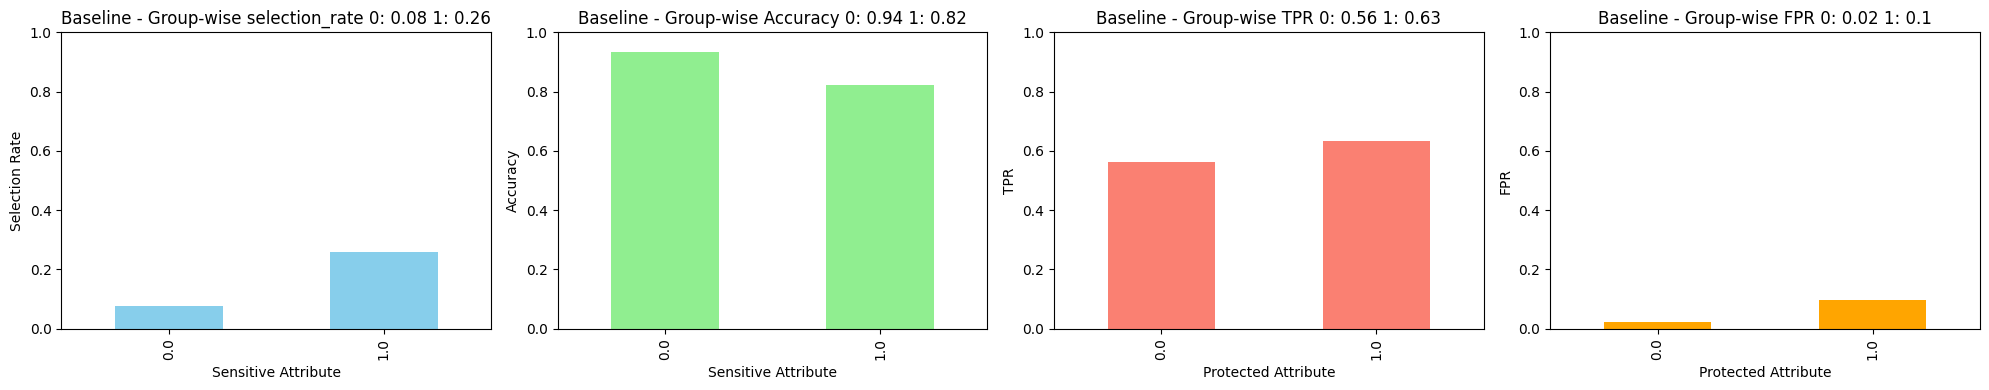

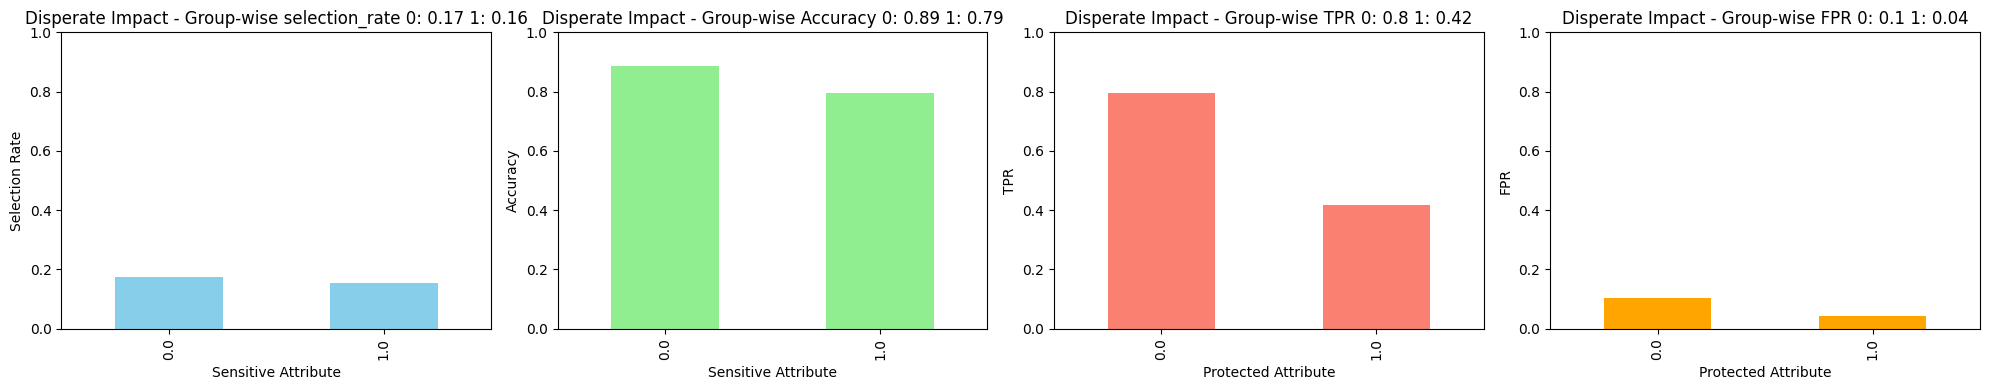

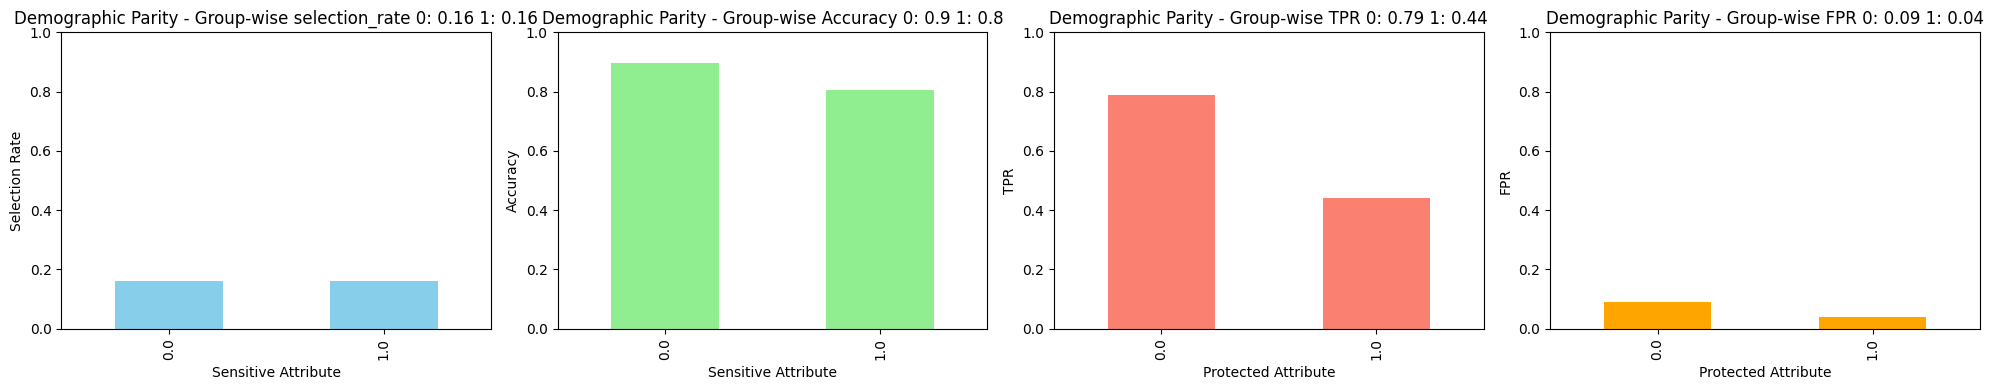

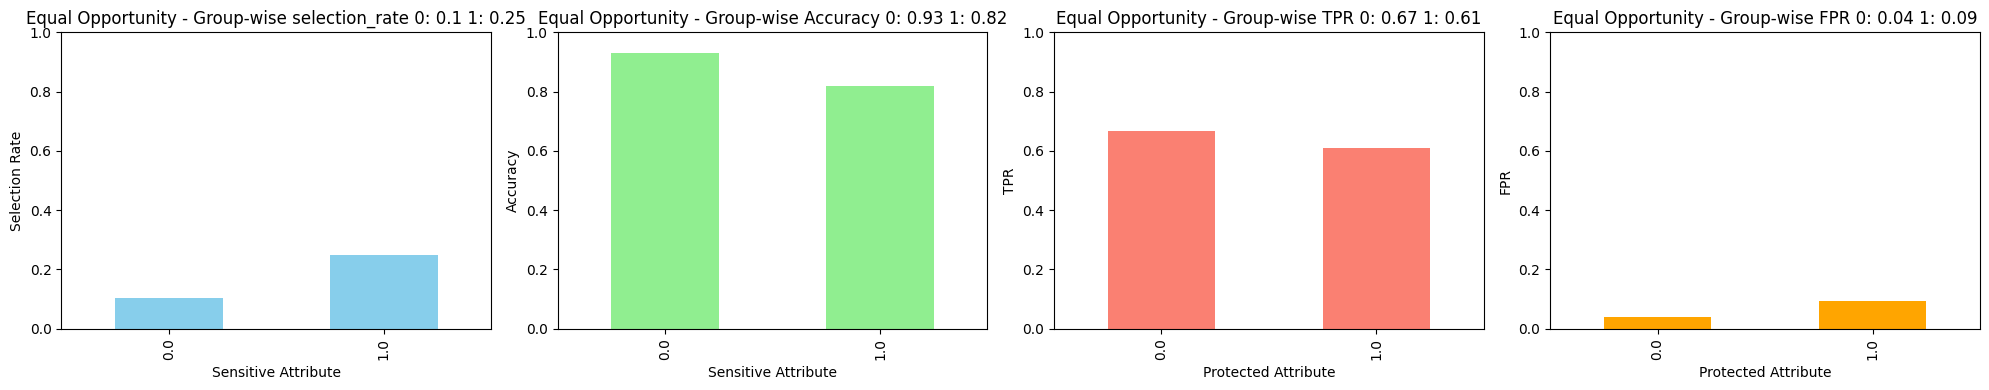

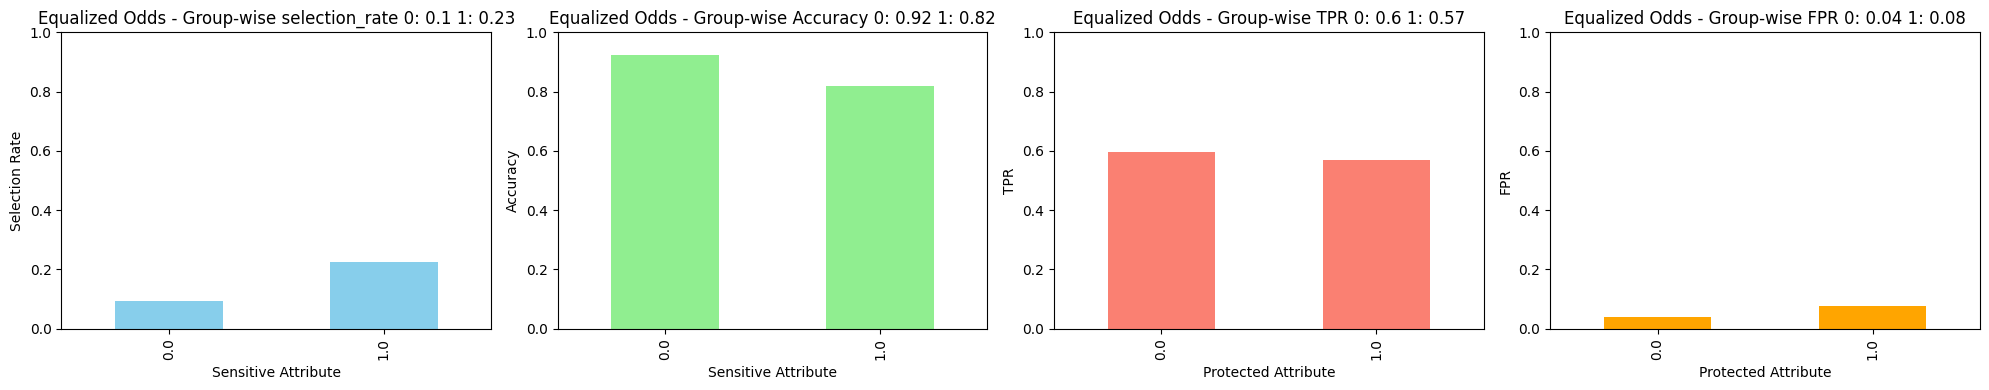

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate
import numpy as np
import torch
from sklearn.metrics import accuracy_score, recall_score
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate

# 모델별 그룹 성능 평가 및 시각화
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).cpu().numpy()
    y_pred_label = (y_pred >= 0.5).astype(int)

    # Metrics 정의
    metrics = {
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'TPR': recall_score,
        'FPR': false_positive_rate
    }

    # MetricFrame을 통한 그룹별 평가
    mf = MetricFrame(metrics=metrics, y_true=y_test_t.cpu().numpy(), y_pred=y_pred_label, sensitive_features=S_test_t.cpu().numpy())

    # 시각화
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))

    mf.by_group['selection_rate'].plot.bar(ax=ax[0], color='skyblue')
    ax[0].set_ylim(0, 1)
    ax[0].set_title(f"{name} - Group-wise selection_rate 0: {mf.by_group['selection_rate'][0].round(2)} 1: {mf.by_group['selection_rate'][1].round(2)}")
    ax[0].set_xlabel('Sensitive Attribute')
    ax[0].set_ylabel('Selection Rate')

    mf.by_group['accuracy'].plot.bar(ax=ax[1], color='lightgreen')
    ax[1].set_ylim(0, 1)
    ax[1].set_title(f"{name} - Group-wise Accuracy 0: {mf.by_group['accuracy'][0].round(2)} 1: {mf.by_group['accuracy'][1].round(2)}")
    ax[1].set_xlabel('Sensitive Attribute')
    ax[1].set_ylabel('Accuracy')

    mf.by_group['TPR'].plot.bar(ax=ax[2], color='salmon')
    ax[2].set_ylim(0, 1)
    ax[2].set_title(f"{name} - Group-wise TPR 0: {mf.by_group['TPR'][0].round(2)} 1: {mf.by_group['TPR'][1].round(2)}")
    ax[2].set_xlabel('Protected Attribute')
    ax[2].set_ylabel('TPR')

    mf.by_group['FPR'].plot.bar(ax=ax[3], color='orange')
    ax[3].set_ylim(0, 1)
    ax[3].set_title(f"{name} - Group-wise FPR 0: {mf.by_group['FPR'][0].round(2)} 1: {mf.by_group['FPR'][1].round(2)}")
    ax[3].set_xlabel('Protected Attribute')
    ax[3].set_ylabel('FPR')

    plt.tight_layout()
    plt.tight_layout()
    plt.show()


2. Fair Regression
- Mean Prediction Parity
- MSE parity
- bounded group loss

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# 데이터 로드
housing = fetch_california_housing()
X, y = housing.data, housing.target
# 가상의 민감 속성 생성 (중간 소득 기준으로 이진화)
median_income = X[:, 0]  # 첫 번째 특성이 중간 소득
S = (median_income > np.median(median_income)).astype(int)



# 데이터 분리
X_train, X_test, y_train, y_test, S_train, S_test = train_test_split(X, y, S, test_size=0.2, random_state=42)

# 데이터 표준화
scaler_reg = StandardScaler()
X_train = scaler_reg.fit_transform(X_train)
X_test = scaler_reg.transform(X_test)

# Tensor 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
S_train_t = torch.tensor(S_train, dtype=torch.int32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
S_test_t = torch.tensor(S_test, dtype=torch.int32)


In [22]:
y_test_t.shape

torch.Size([4128, 1])

In [23]:
class regressor_simple(nn.Module):
  def __init__(self, input_dim):
    super(regressor_simple, self).__init__()
    self.fc = nn.Linear(input_dim, 1)

  def forward(self, x):
    return self.fc(x)

# Neural Network Model for Regression
class regressor(nn.Module):
  def __init__(self, input_dim):
    super(regressor, self).__init__()
    self.fc = nn.Sequential(
        nn.Linear(input_dim, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        )
  def forward(self, x):
    return self.fc(x)

# 회귀 모델 정의
class regresssor_deep(nn.Module):
  def __init__(self, input_size):
    super(regresssor_deep, self).__init__()
    self.fc1 = nn.Linear(input_size, 32)
    self.fc2 = nn.Linear(32, 16)
    self.fc3 = nn.Linear(16, 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x) #####
    return x

In [24]:
# 공정성 손실 함수 정의
def fairness_loss(y_pred, S, fairness_type='mean'):
  group_0 = (S == 0)
  group_1 = (S == 1)

  if fairness_type == 'mean':
    return torch.abs(y_pred[group_0].mean() - y_pred[group_1].mean())
  elif fairness_type == 'mse':
    mse_0 = ((y_train_t[group_0] - y_pred[group_0]) ** 2).mean()
    mse_1 = ((y_train_t[group_1] - y_pred[group_1]) ** 2).mean()
    return torch.abs(mse_0 - mse_1)
  elif fairness_type == 'bounded':
    mse_0 = ((y_train_t[group_0] - y_pred[group_0]) ** 2).mean()
    mse_1 = ((y_train_t[group_1] - y_pred[group_1]) ** 2).mean()
    bound = 0.5
    return torch.relu(mse_0 - bound) + torch.relu(mse_1 - bound)

In [25]:
# 모델 학습 함수
def train_model(fairness_type=None, epochs=100, lambda_fair=0.5):
  model = regressor(X_train.shape[1])
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=0.01)

  model.train()
  for epoch in range(epochs):
      model.train()
      optimizer.zero_grad()
      y_pred = model(X_train_t)
      loss = criterion(y_pred, y_train_t)

      if fairness_type:
        loss += lambda_fair * fairness_loss(y_pred, S_train_t, fairness_type=fairness_type)

      loss.backward()
      optimizer.step()

  return model

# 모델 학습
models = {
    'Baseline': train_model(fairness_type=None),
    'Mean Prediction Fairness': train_model(fairness_type='mean'),
    'MSE Parity': train_model(fairness_type='mse'),
    'Bounded Group Loss': train_model(fairness_type='bounded')
}


In [26]:
# 평가 및 시각화 (MSE와 평균 예측값)
results = {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t)
    mse_group_0 = ((y_test_t[S_test_t==0] - y_pred[S_test_t==0]) ** 2).mean().item()
    mse_group_1 = ((y_test_t[S_test_t==1] - y_pred[S_test_t==1]) ** 2).mean().item()
    mean_pred_group_0 = y_pred[S_test_t==0].mean().item()
    mean_pred_group_1 = y_pred[S_test_t==1].mean().item()

    results[name] = {
        'Group 0 MSE': mse_group_0,
        'Group 1 MSE': mse_group_1,
        'Group 0 Mean Prediction': mean_pred_group_0,
        'Group 1 Mean Prediction': mean_pred_group_1
    }

# 시각화
labels = list(results.keys())
group_0_mse = [results[label]['Group 0 MSE'] for label in labels]
group_1_mse = [results[label]['Group 1 MSE'] for label in labels]
group_0_mean = [results[label]['Group 0 Mean Prediction'] for label in labels]
group_1_mean = [results[label]['Group 1 Mean Prediction'] for label in labels]

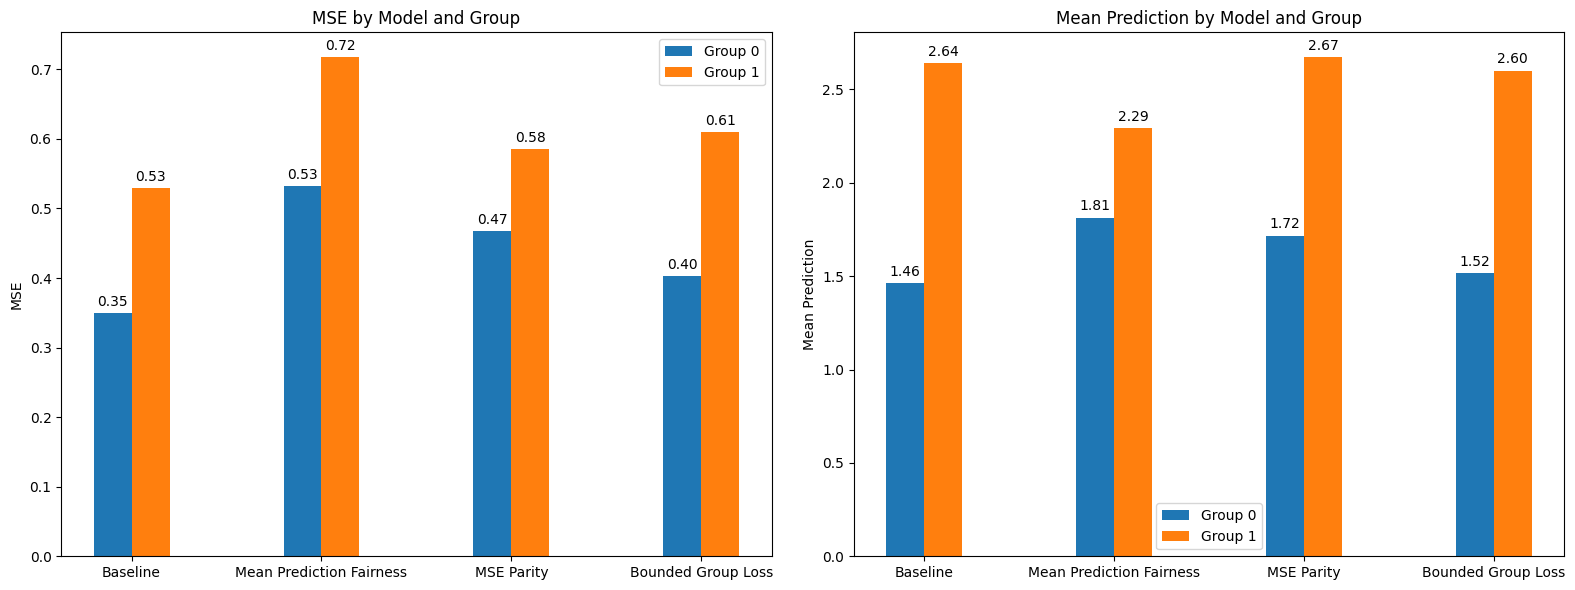

In [27]:
x = np.arange(len(labels)) # array([0, 1, 2, 3])
width = 0.2 # 막대 그래프의 각 막대의 너비(width)를 의미

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MSE 시각화
rects1 = ax1.bar(x - width/2, group_0_mse, width, label='Group 0')
rects2 = ax1.bar(x + width/2, group_1_mse, width, label='Group 1')
ax1.set_ylabel('MSE')
ax1.set_title('MSE by Model and Group')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.bar_label(rects1, padding=3, fmt='%.2f')
ax1.bar_label(rects2, padding=3, fmt='%.2f')

# Mean Prediction 시각화
rects3 = ax2.bar(x - width/2, group_0_mean, width, label='Group 0')
rects4 = ax2.bar(x + width/2, group_1_mean, width, label='Group 1')
ax2.set_ylabel('Mean Prediction')
ax2.set_title('Mean Prediction by Model and Group')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.bar_label(rects3, padding=3, fmt='%.2f')
ax2.bar_label(rects4, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()